<a href="https://colab.research.google.com/github/RishiRaj0004/BHARAT-INTERN/blob/main/Predict_Weather_Condition1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
datasetengineer_integrated_emergency_response_dataset_ierad_path = kagglehub.dataset_download('datasetengineer/integrated-emergency-response-dataset-ierad')

print('Data source import complete.')


Using Colab cache for faster access to the 'integrated-emergency-response-dataset-ierad' dataset.
Data source import complete.


In [4]:

# STEP 1️ : Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

import warnings
warnings.filterwarnings("ignore")


In [5]:

# STEP 2️ : Load the dataset

data = pd.read_csv("/kaggle/input/integrated-emergency-response-dataset-ierad/emergency_service_routing_with_timestamps.csv")

print(" Data loaded successfully!")
print("Shape:", data.shape)
print("\nMissing values per column:\n", data.isna().sum())

# Preview first few rows
data.head()


 Data loaded successfully!
Shape: (368065, 24)

Missing values per column:
 Timestamp                       0
Incident_Severity               0
Incident_Type                   0
Region_Type                     0
Traffic_Congestion              0
Weather_Condition               0
Drone_Availability              0
Ambulance_Availability          0
Battery_Life                    0
Air_Traffic                     0
Response_Time                   0
Hospital_Capacity               0
Distance_to_Incident            0
Number_of_Injuries              0
Specialist_Availability         0
Road_Type                       0
Emergency_Level                 0
Drone_Speed                     0
Ambulance_Speed                 0
Payload_Weight                  0
Fuel_Level                      0
Weather_Impact             257597
Dispatch_Coordinator            0
Label                           0
dtype: int64


,Timestamp,Incident_Severity,Incident_Type,Region_Type,Traffic_Congestion,Weather_Condition,Drone_Availability,Ambulance_Availability,Battery_Life,Air_Traffic,...,Specialist_Availability,Road_Type,Emergency_Level,Drone_Speed,Ambulance_Speed,Payload_Weight,Fuel_Level,Weather_Impact,Dispatch_Coordinator,Label
0,2018-01-01 00:00:00,Low,Cardiac Arrest,Suburban,High,Clear,Available,Available,71.177951,Low,...,Unavailable,Highway,Major,59.578538,43.549849,9.28,90.030756,Severe,AI,Ambulance Only
1,2018-01-01 00:10:00,Low,Other,Urban,Moderate,Clear,Available,Available,70.949595,Low,...,Unavailable,Highway,Critical,74.578440,30.687975,9.47,88.255008,Moderate,Human,Ambulance Only
2,2018-01-01 00:20:00,Medium,Cardiac Arrest,Suburban,High,Rainy,Unavailable,Available,74.346037,Medium,...,Unavailable,Unpaved Road,Minor,45.900425,44.456331,8.77,97.719622,NaN,Human,Hybrid Dispatch
3,2018-01-01 00:30:00,Low,Accident,Urban,Moderate,Clear,Available,Available,84.199630,Medium,...,Available,Highway,Minor,50.927769,35.879968,4.76,60.234672,NaN,Human,Ambulance Only
4,2018-01-01 00:40:00,Low,Cardiac Arrest,Urban,Moderate,Stormy,Available,Available,78.492584,Low,...,Available,Highway,Minor,71.312741,26.369383,3.83,71.083564,Moderate,Human,Ambulance Only


In [6]:

# STEP 3️ : Handle missing values

# The only column with missing data is 'Weather_Impact'
# Let's fill it with 'Unknown' so model can handle it as a new category

data['Weather_Impact'] = data['Weather_Impact'].fillna('Unknown')

print(" Missing values handled!")
print("Remaining NaNs:", data['Weather_Impact'].isna().sum())


 Missing values handled!
Remaining NaNs: 0


In [7]:

# STEP 4️ : Select target and recommended features


target = "Weather_Condition"

# Recommended features from previous analysis
features = [
    'Region_Type', 'Traffic_Congestion', 'Air_Traffic',
    'Weather_Impact', 'Incident_Severity', 'Road_Type',
    'Emergency_Level', 'Drone_Availability'
]

# Define input (X) and output (y)
X = data[features]
y = data[target]

print(" Target:", target)
print(" Features used:", features)
print("\nUnique Weather Conditions:\n", y.value_counts())


 Target: Weather_Condition
 Features used: ['Region_Type', 'Traffic_Congestion', 'Air_Traffic', 'Weather_Impact', 'Incident_Severity', 'Road_Type', 'Emergency_Level', 'Drone_Availability']

Unique Weather Conditions:
 Weather_Condition
Clear     294668
Rainy      55105
Stormy     18292
Name: count, dtype: int64


In [8]:

# STEP 5️ : Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # maintain same distribution of weather types
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (294452, 8)
Testing data shape: (73613, 8)


In [9]:

# STEP 6️ : Identify column types

numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: []
Categorical columns: ['Region_Type', 'Traffic_Congestion', 'Air_Traffic', 'Weather_Impact', 'Incident_Severity', 'Road_Type', 'Emergency_Level', 'Drone_Availability']


In [10]:

# STEP 7️ : Create preprocessing pipelines

# Numeric pipeline: fill missing with median + scale
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline: fill missing with mode + OneHotEncode
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine both using ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])


In [11]:

# STEP 8️ : Build and train the model

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

print(" Training model...")
model.fit(X_train, y_train)
print(" Model training completed!")


 Training model...
 Model training completed!


 Accuracy: 79.96%

📋 Classification Report:
               precision    recall  f1-score   support

       Clear       0.80      1.00      0.89     58934
       Rainy       0.14      0.00      0.00     11021
      Stormy       0.05      0.00      0.00      3658

    accuracy                           0.80     73613
   macro avg       0.33      0.33      0.30     73613
weighted avg       0.66      0.80      0.71     73613



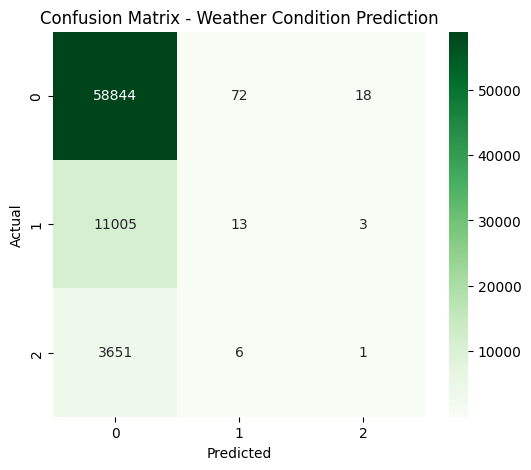

In [12]:

# STEP 9️: Evaluate the model

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f" Accuracy: {acc*100:.2f}%\n")

print("📋 Classification Report:\n", classification_report(y_test, y_pred))

# Visualize confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Weather Condition Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


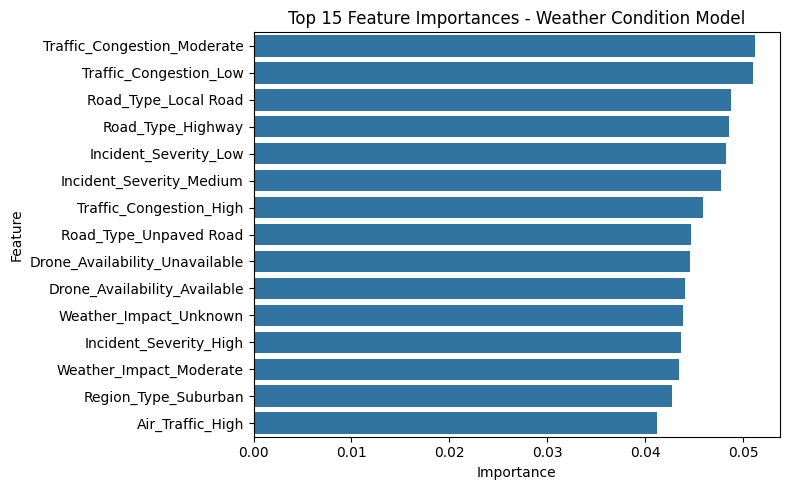

In [13]:

# STEP  : Check feature importance

def get_feature_names(preprocessor):
    feature_names = []
    for name, transformer, cols in preprocessor.transformers_:
        if name == "num":
            feature_names.extend(cols)
        elif name == "cat":
            ohe = transformer.named_steps["encoder"]
            feature_names.extend(ohe.get_feature_names_out(cols))
    return feature_names

feature_names = get_feature_names(preprocessor)
importances = model.named_steps["classifier"].feature_importances_

feat_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Plot top 15 important features
plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=feat_imp_df.head(15))
plt.title("Top 15 Feature Importances - Weather Condition Model")
plt.tight_layout()
plt.show()


In [14]:

# STEP 1️1 : Save model for later use

joblib.dump(model, "weather_condition_model.joblib")
print(" Model saved as 'weather_condition_model.joblib' successfully!")


 Model saved as 'weather_condition_model.joblib' successfully!
